In [1]:
import torch
from torch_geometric.data import Data
import torch.nn as nn

/Users/tungvuduc/opt/anaconda3/envs/dlbio_arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.data import Data

dataset = Planetoid(root="/tmp/planetoid", transform=NormalizeFeatures(), name="Cora")

# inspecting the dataset
print(f"Number of graphs: {len(dataset)}")
data = dataset[0]

print(f"Number of nodes: {data.num_nodes}")
print(f"Number of features: {data.num_features}")
print(f"Number of edges: {data.num_edges}")

print(f"Number of classes: {dataset.num_classes}")

print(f"Does the graph have isolated nodes? {data.has_isolated_nodes()}")
print(f"The average node degree is : {(data.edge_index.shape[1]/data.num_nodes):.2f}")
print(f"Does the graph have self-loops: {data.has_self_loops()}")
print(f"Is the graph undirected {data.is_undirected()}")
print(f"Number of labels: {data.y.unique()}")
print(f"Nodel label rate: {data.train_mask.sum()/data.num_nodes:.2f}")

Number of graphs: 1
Number of nodes: 2708
Number of features: 1433
Number of edges: 10556
Number of classes: 7
Does the graph have isolated nodes? False
The average node degree is : 3.90
Does the graph have self-loops: False
Is the graph undirected True
Number of labels: tensor([0, 1, 2, 3, 4, 5, 6])
Nodel label rate: 0.05


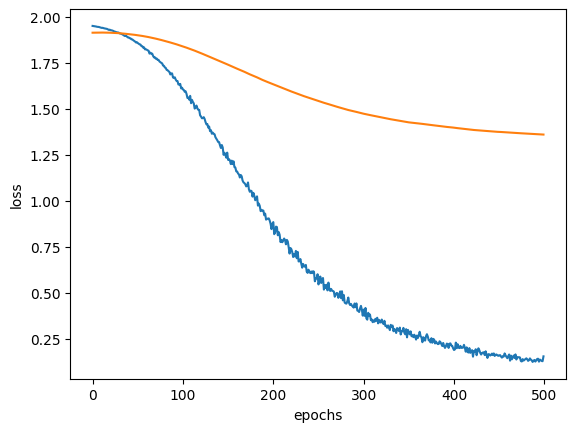

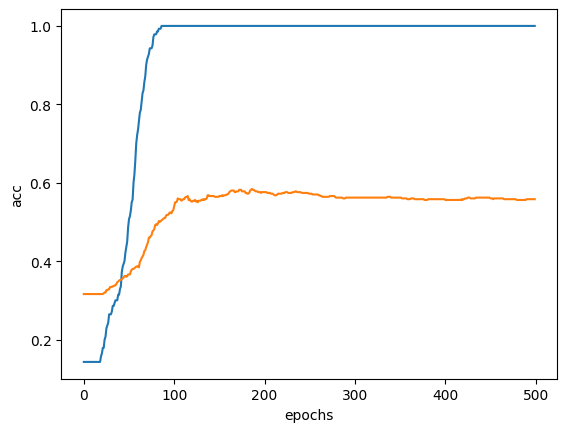

In [5]:
# let us try a simple MLP to predict the classes
from torch.functional import F

class MLP(nn.Module):

    def __init__(self, in_channels: int, hidden_channels: int, p: float, num_classes: int):
        super().__init__()
        torch.manual_seed(42)

        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.p = p
        self.num_classes = num_classes

        self.linear = nn.Sequential(
            nn.Linear(self.in_channels, self.hidden_channels),
            nn.ReLU(),
            nn.Dropout(p=self.p),
        )

        self.classifier_head = nn.Linear(self.hidden_channels, self.num_classes)

    def forward(self, x: torch.Tensor):

        hidden = self.linear(x)
        x = self.classifier_head(hidden)
        return x, hidden

num_classes = len(data.y.unique())
in_channels = data.num_features
hidden_channels = 64
epochs = 500

model = MLP(in_channels=in_channels, hidden_channels=hidden_channels, p=0.5, num_classes=num_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


def train(model: MLP, data: Data, loss: nn.CrossEntropyLoss, optimizer: torch.optim.Adam):
    
        model.train()
        optimizer.zero_grad()
        out, _ = model(data.x[data.train_mask])
        loss = criterion(out, data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        return loss

def eval(model: MLP, data: Data, loss: nn.CrossEntropyLoss):
    model.eval()
     
    with torch.no_grad():
        out, _ = model(data.x[data.val_mask])
        loss = criterion(out, data.y[data.val_mask])
        return loss

def calculate_accuracy(model: MLP, data: Data, mask: torch.Tensor):
    out = torch.argmax(model(data.x[mask])[0], dim=1)
    return (out == data.y[mask]).float().mean().item()


train_loss = []
val_loss = []
train_acc = []
val_acc = []

for epoch in range(epochs):
    train_loss.append(train(model, data, criterion, optimizer).detach().numpy())
    val_loss.append(eval(model, data, criterion).detach().numpy())

    train_acc.append(calculate_accuracy(model, data, data.train_mask))
    val_acc.append(calculate_accuracy(model, data, data.val_mask))

import matplotlib.pyplot as plt

plt.plot(train_loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

plt.plot(train_acc, label="train_acc")
plt.plot(val_acc, label="val_acc")
plt.xlabel("epochs")
plt.ylabel("acc")
plt.show()

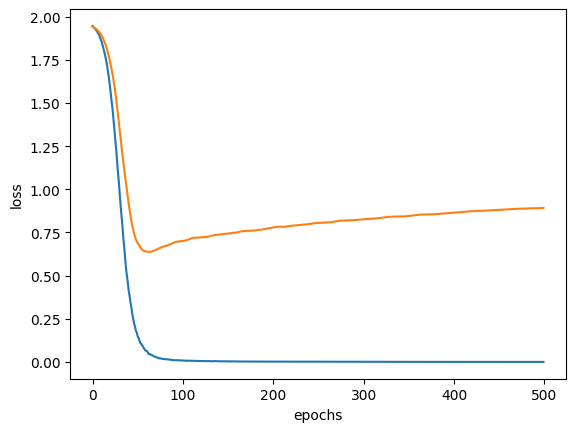

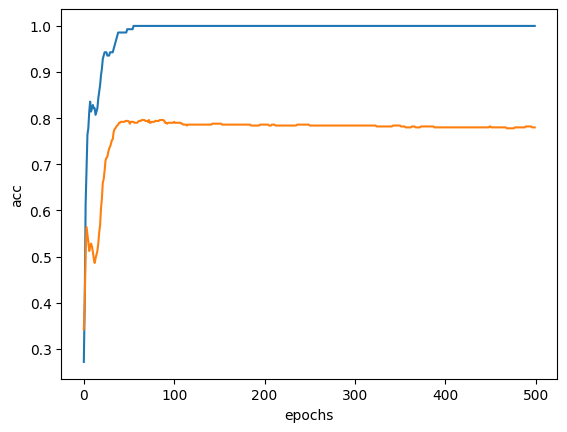

In [6]:
# let's try a GCNConv for node classification

from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int, p: float):
        super().__init__()

        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        self.p = p
        self.dropout = nn.Dropout(p=self.p)

        self.conv_in = GCNConv(
            in_channels=self.in_channels,
            out_channels=self.hidden_channels,
            add_self_loops=True
            )
        
        self.conv_out = GCNConv(
            in_channels=self.hidden_channels,
            out_channels=self.hidden_channels,
            add_self_loops=True
        )

        self.classifier_head = nn.Linear(
            self.hidden_channels, self.out_channels
            )
        
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        x = self.conv_in(x, edge_index)
        x = self.dropout(x)
        h = self.conv_out(x, edge_index)
        x = self.dropout(h)
        return self.classifier_head(x), h
    
in_channels = data.num_features
hidden_channels = 512
out_channels = len(data.y.unique())

gcn_model = GCN(in_channels, hidden_channels, out_channels, p=0.5)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.001)

def train(model: GCN, x: torch.Tensor, edge_index: torch.Tensor, y: torch.Tensor, criterion: nn.CrossEntropyLoss, optimizer: torch.optim.Adam, mask: torch.Tensor):

    model.train()
    optimizer.zero_grad()
    out, _ = model(x, edge_index)
    loss = criterion(out[mask], y[mask])
    loss.backward()
    optimizer.step()

    return loss.item()

def val(model: GCN, x: torch.Tensor, edge_index: torch.Tensor, y: torch.Tensor, criterion: nn.CrossEntropyLoss, mask: torch.Tensor, ):
    model.eval()
    with torch.no_grad():
        out, _ = model(x, edge_index)
        loss = criterion(out[mask], y[mask])
        return loss.item()

def acc(model: GCN, x: torch.Tensor, edge_index: torch.Tensor, y: torch.Tensor, mask: torch.Tensor):
    model.eval()
    with torch.no_grad():
        out, _ = model(x, edge_index)
        y_pred = torch.argmax(F.sigmoid(out), dim=1)
        acc = (y[mask] == y_pred[mask]).float().mean()
        return acc.item()

epochs = 500

train_loss = []
val_loss = []

train_acc = []
val_acc = []
for epoch in range(epochs):
    train_loss.append(train(gcn_model, data.x, data.edge_index, data.y, criterion, optimizer, data.train_mask))
    val_loss.append(val(gcn_model, data.x, data.edge_index, data.y, criterion, data.val_mask))
    train_acc.append(acc(gcn_model, data.x, data.edge_index, data.y, data.train_mask))
    val_acc.append(acc(gcn_model, data.x, data.edge_index, data.y, data.val_mask))


import matplotlib.pyplot as plt

plt.plot(train_loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

plt.plot(train_acc, label="train_acc")
plt.plot(val_acc, label="val_acc")
plt.xlabel("epochs")
plt.ylabel("acc")
plt.show()

In [ ]:
from sklearn.manifold import TSNE

hidden_gcn = gcn_model(data.x, data.edge_index)[1][data.test_mask].detach().numpy()
hidden_mlp = model(data.x[data.test_mask])[1].detach().numpy()

transformer = TSNE()
hidden_gcn_tf = transformer.fit_transform(hidden_gcn)
mlp_tf = transformer.fit_transform(hidden_mlp)

gcn_out = gcn_model(data.x, data.edge_index)[0][data.test_mask].detach().numpy()
mlp_out = model(data.x[data.test_mask])[0].detach().numpy()

gcn_acc = acc(gcn_model, data.x, data.edge_index, data.y, data.test_mask)
mlp_acc = calculate_accuracy(model, data, data.test_mask)

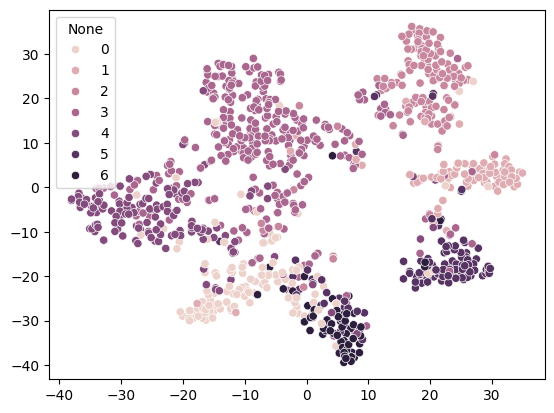

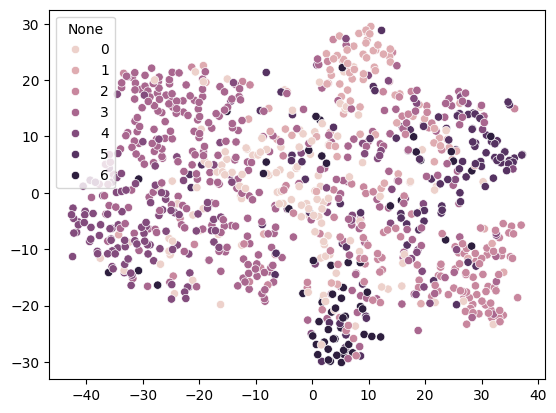

In [16]:
import seaborn as sns

sns.scatterplot(
    x=hidden_gcn_tf[:, 0],
    y=hidden_gcn_tf[:, 1],
    hue=data.y[data.test_mask],
)
plt.show()

sns.scatterplot(
    x=mlp_tf[:, 0],
    y=mlp_tf[:, 1],
    hue=data.y[data.test_mask],
)
plt.show()
